# Publication-Quality Survival Visualisation in R

## Overview

This notebook consolidates survival plot templates from `kaplan_meier.ipynb` and `cox_proportional_hazards.ipynb` into reusable, publication-ready ggplot2 code. Focus is on the design decisions that distinguish a publication figure from a default output.

**Mandatory elements in any survival figure:**
- Risk table (n at risk) — essential for interpreting curve reliability at late time points
- Censoring marks — tick marks on the curve at censoring times
- Confidence intervals — 95% CI bands, appropriately shaded
- Median survival lines — horizontal/vertical drop to x-axis
- Test result — log-rank p-value in a consistent position

---

## Setup

In [1]:
library(tidyverse)
library(survival)
library(survminer)
library(broom)
library(patchwork)
library(scales)

set.seed(42)

n <- 200
surv_data <- tibble(
  id          = 1:n,
  habitat     = factor(rep(c("reference","restored","degraded"), length.out=n),
                       levels=c("reference","restored","degraded")),
  water_qual  = rnorm(n, 6, 1.5),
  true_t      = c(rexp(ceiling(n/3),0.10), rexp(ceiling(n/3),0.06),
                  rexp(floor(n/3),0.03))[1:n]
) %>%
  mutate(status=as.integer(true_t<=35), time=pmin(true_t,35))

km_fit  <- survfit(Surv(time,status) ~ habitat, data=surv_data, conf.type="log-log")
lr      <- survdiff(Surv(time,status) ~ habitat, data=surv_data)
lr_p    <- 1 - pchisq(lr$chisq, df=2)
km_tidy <- broom::tidy(km_fit) %>% mutate(habitat=str_remove(strata,"habitat="))

pal <- c(reference="#4a8fff", restored="#4fffb0", degraded="#ff6b6b")

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'survival' was built under R version 4.4.3"
Warning message:
"package 'survminer' was built under R version

---

## Template 1: survminer Standard Format

Ignoring unknown labels:
• colour : "Habitat type"


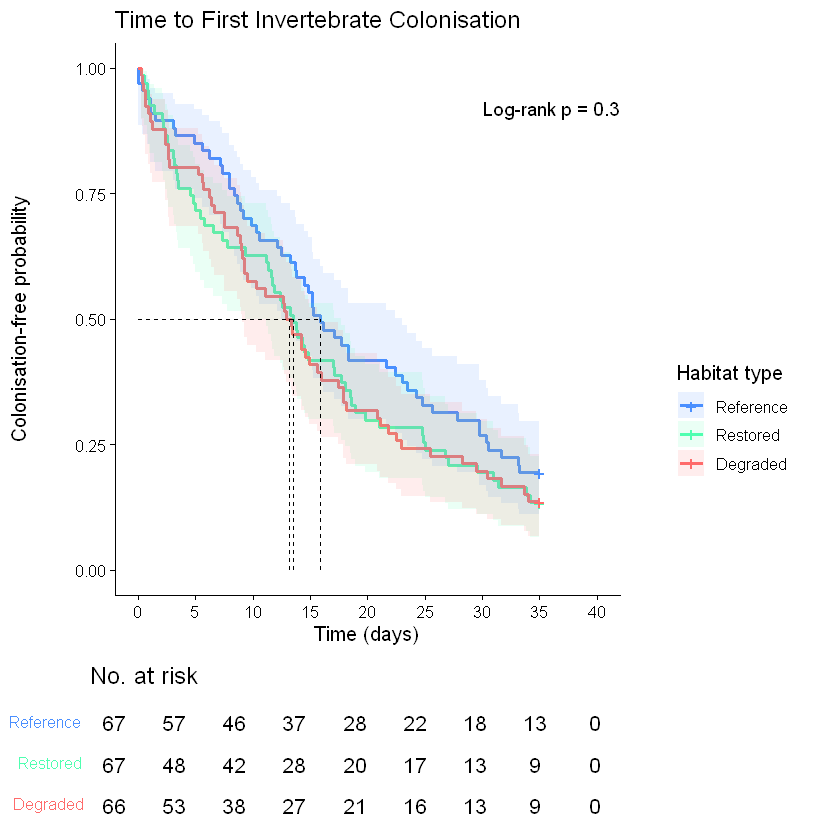

In [2]:
# The survminer default with all required elements
# Recommended for most ecological and clinical publications

survminer::ggsurvplot(
  km_fit,
  data              = surv_data,

  # Annotations
  pval              = sprintf("Log-rank p = %.3f", lr_p),
  pval.size         = 4,
  pval.coord        = c(30, 0.92),

  # Confidence intervals
  conf.int          = TRUE,
  conf.int.alpha    = 0.12,
  conf.int.style    = "ribbon",

  # Censoring marks
  censor            = TRUE,
  censor.shape      = "+",
  censor.size       = 4,

  # Median lines
  surv.median.line  = "hv",

  # Risk table
  risk.table        = TRUE,
  risk.table.title  = "No. at risk",
  risk.table.height = 0.22,
  risk.table.y.text = TRUE,
  tables.theme      = theme_cleantable(),

  # Colours and labels
  palette           = unname(pal),
  legend.title      = "Habitat type",
  legend.labs       = c("Reference","Restored","Degraded"),
  legend            = "right",

  # Axes
  xlab              = "Time (days)",
  ylab              = "Colonisation-free probability",
  ylim              = c(0, 1),
  break.time.by     = 5,

  title             = "Time to First Invertebrate Colonisation",
  ggtheme           = theme_classic(base_size = 12)
)

---

## Template 2: Full ggplot2 (Maximum Customisation)

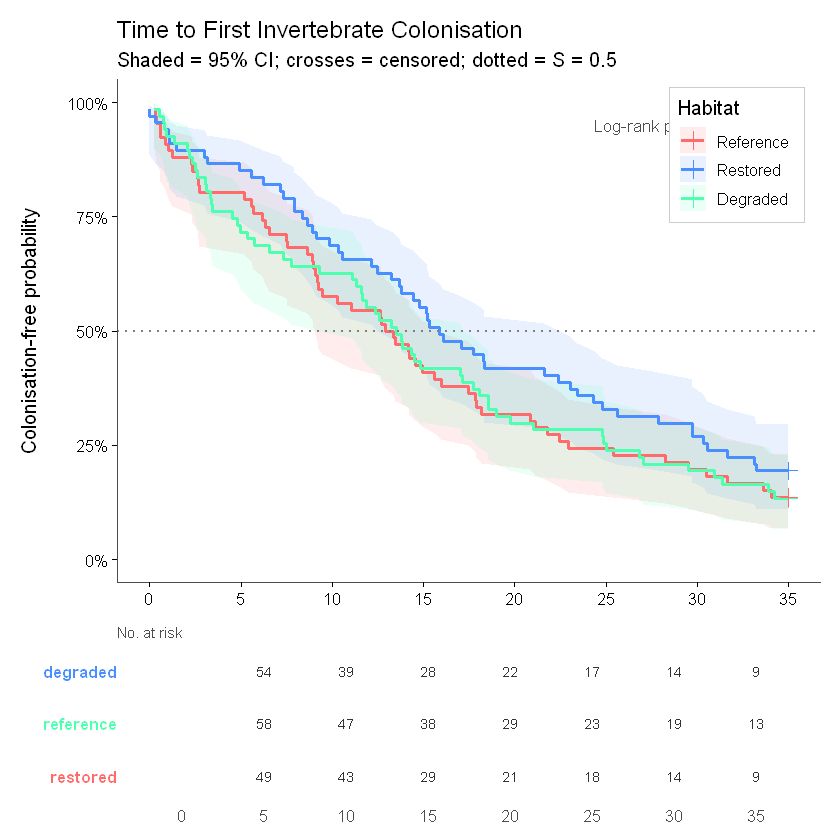

In [3]:
# Build every element manually for complete control

# ── Main survival curve ───────────────────────────────────────────────────────
p_main <- km_tidy %>%
  ggplot(aes(x=time, y=estimate, color=habitat, fill=habitat)) +

  # CI ribbon
  geom_ribbon(aes(ymin=conf.low, ymax=conf.high),
              alpha=0.12, color=NA) +

  # Survival step function
  geom_step(linewidth=1) +

  # Censoring tick marks
  geom_point(data=~filter(.x, n.censor > 0),
             shape=3, size=3, stroke=0.8) +

  # Median lines (manual: draw at S=0.5)
  geom_hline(yintercept=0.5, linetype="dotted", color="gray50", linewidth=0.6) +

  # p-value annotation
  annotate("text",
           x=32, y=0.95,
           label=sprintf("Log-rank p = %.3f", lr_p),
           hjust=1, size=3.5, color="gray30") +

  scale_color_manual(values=pal,
    labels=c("Reference","Restored","Degraded")) +
  scale_fill_manual(values=pal,
    labels=c("Reference","Restored","Degraded")) +
  scale_y_continuous(limits=c(0,1), labels=percent_format(accuracy=1)) +
  scale_x_continuous(breaks=seq(0,35,5)) +

  labs(title    = "Time to First Invertebrate Colonisation",
       subtitle  = "Shaded = 95% CI; crosses = censored; dotted = S = 0.5",
       x = NULL, y = "Colonisation-free probability",
       color = "Habitat", fill = "Habitat") +
  theme_classic(base_size=12) +
  theme(
    legend.position = c(0.88, 0.85),
    legend.background = element_rect(fill="white", color="gray80"),
    axis.line = element_line(color="gray30")
  )

# ── Risk table ────────────────────────────────────────────────────────────────
# Build manually from km_tidy
risk_times <- seq(0, 35, by=5)
risk_table <- map_dfr(risk_times, function(tpt) {
  km_tidy %>%
    group_by(habitat) %>%
    filter(time <= tpt) %>%
    slice_tail(n=1) %>%
    ungroup() %>%
    transmute(habitat, time_pt=tpt, n_risk=n.risk)
})

p_risk <- ggplot(risk_table, aes(x=time_pt, y=fct_rev(habitat), label=n_risk)) +
  geom_text(size=3, color="gray20") +
  scale_x_continuous(breaks=seq(0,35,5), limits=c(-2,37)) +
  labs(x="Time (days)", y=NULL, title="No. at risk") +
  theme_void(base_size=10) +
  theme(
    axis.text.x = element_text(color="gray30"),
    axis.text.y = element_text(color=rev(unname(pal)), hjust=1, face="bold"),
    plot.title  = element_text(size=9, color="gray30"),
    plot.margin = margin(0, 5, 5, 5)
  )

# Combine with patchwork
(p_main / p_risk) + plot_layout(heights=c(3,1))

---

## Template 3: Cox Model Adjusted Survival Curves

In [7]:
adj_tidy <- broom::tidy(adj_fit)
cat("Columns:", names(adj_tidy), "\n")
print(head(adj_tidy))

Columns: time n.risk n.event n.censor estimate.1 estimate.2 estimate.3 std.error.1 std.error.2 std.error.3 conf.high.1 conf.high.2 conf.high.3 conf.low.1 conf.low.2 conf.low.3 


# A tibble: 6 × 16
     time n.risk n.event n.censor estimate.1 estimate.2 estimate.3 std.error.1
    <dbl>  <dbl>   <dbl>    <dbl>      <dbl>      <dbl>      <dbl>       <dbl>
1 0.00468    200       1        0      0.996      0.995      0.995     0.00420
2 0.00994    199       1        0      0.992      0.989      0.989     0.00599
3 0.265      198       1        0      0.988      0.984      0.984     0.00741
4 0.283      197       1        0      0.983      0.979      0.978     0.00863
5 0.298      196       1        0      0.979      0.973      0.973     0.00974
6 0.336      195       1        0      0.975      0.968      0.968     0.0108 
# ℹ 8 more variables: std.error.2 <dbl>, std.error.3 <dbl>, conf.high.1 <dbl>,
#   conf.high.2 <dbl>, conf.high.3 <dbl>, conf.low.1 <dbl>, conf.low.2 <dbl>,
#   conf.low.3 <dbl>


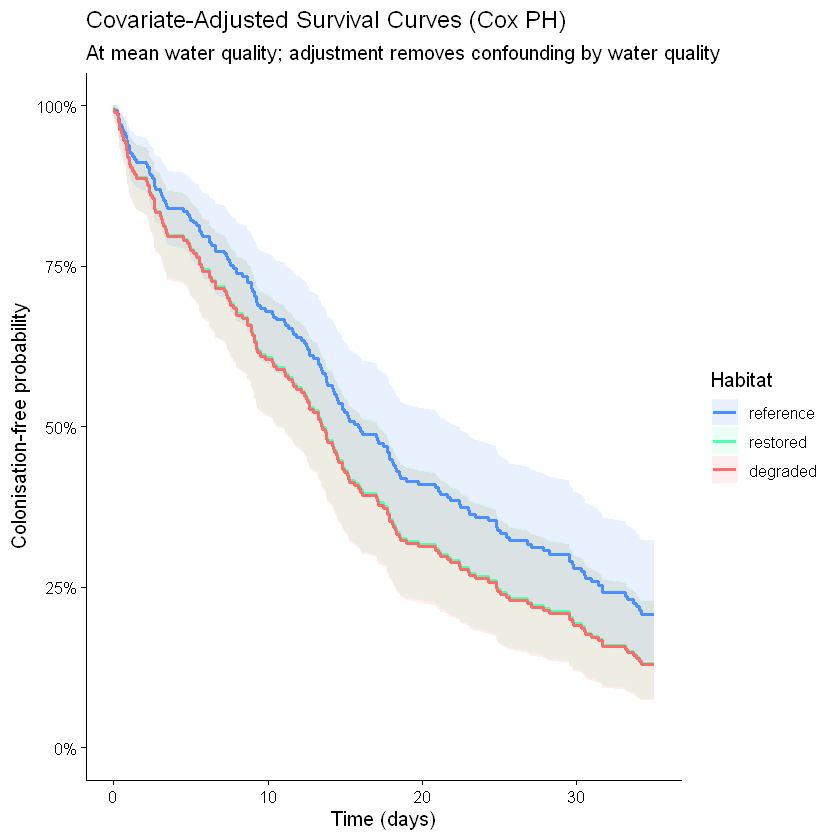

In [9]:
adj_tidy <- broom::tidy(adj_fit) %>%
  dplyr::select(time, starts_with("estimate."), starts_with("conf.low."), starts_with("conf.high.")) %>%
  pivot_longer(
    cols         = -time,
    names_to     = c(".value", "group"),
    names_pattern = "^(estimate|conf\\.low|conf\\.high)\\.(\\d+)$"
  ) %>%
  mutate(habitat = factor(
    levels(surv_data$habitat)[as.integer(group)],
    levels = levels(surv_data$habitat)
  ))

ggplot(adj_tidy, aes(x = time, y = estimate, color = habitat, fill = habitat)) +
  geom_ribbon(aes(ymin = conf.low, ymax = conf.high), alpha = 0.12, color = NA) +
  geom_step(linewidth = 1) +
  scale_color_manual(values = pal) +
  scale_fill_manual(values = pal) +
  scale_y_continuous(limits = c(0, 1), labels = scales::percent_format(accuracy = 1)) +
  labs(title    = "Covariate-Adjusted Survival Curves (Cox PH)",
       subtitle = "At mean water quality; adjustment removes confounding by water quality",
       x = "Time (days)", y = "Colonisation-free probability",
       color = "Habitat", fill = "Habitat") +
  theme_classic(base_size = 12)

---

## Template 4: Multi-Panel Figure for Publication

Warning message:
"The `fatten` argument of `geom_pointrange()` is deprecated as of ggplot2 4.0.0.
ℹ Please use the `size` aesthetic instead."


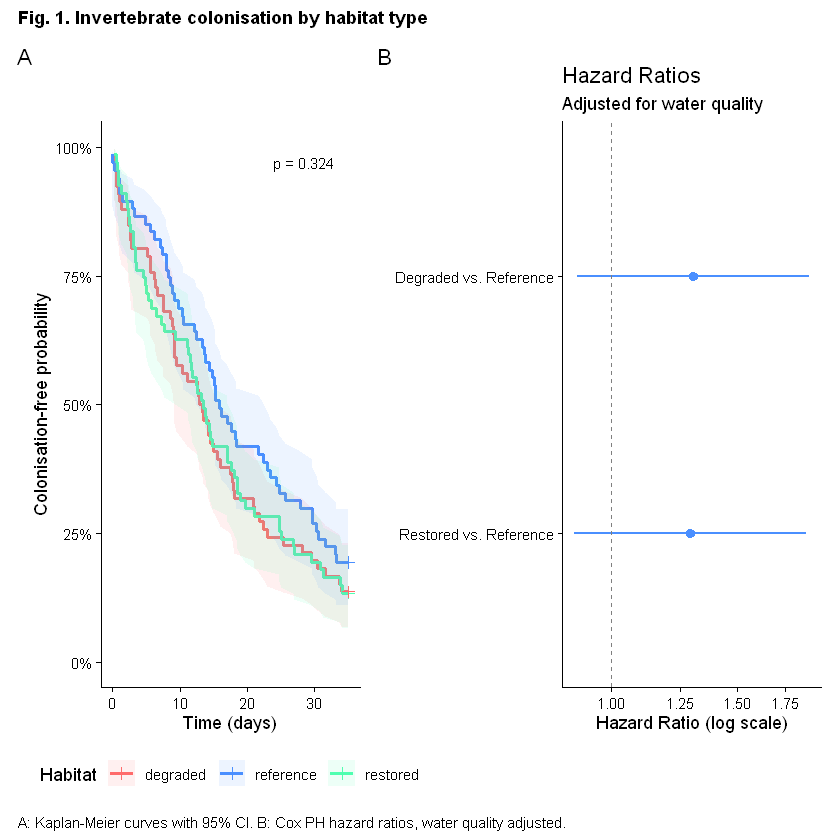

In [10]:
# Panel A: KM curves; Panel B: HR forest plot

p_A <- km_tidy %>%
  ggplot(aes(x=time, y=estimate, color=habitat)) +
  geom_step(linewidth=0.9) +
  geom_ribbon(aes(ymin=conf.low, ymax=conf.high, fill=habitat),
              alpha=0.10, color=NA) +
  geom_point(data=~filter(.x,n.censor>0), shape=3, size=2) +
  scale_color_manual(values=pal) +
  scale_fill_manual(values=pal) +
  scale_y_continuous(limits=c(0,1), labels=percent_format(accuracy=1)) +
  annotate("text", x=33, y=0.97,
           label=sprintf("p = %.3f", lr_p), hjust=1, size=3.2) +
  labs(tag="A", x="Time (days)", y="Colonisation-free probability",
       color="Habitat", fill="Habitat") +
  theme_classic(base_size=11) +
  theme(legend.position="bottom")

cox_tidy <- broom::tidy(cox_fit, exponentiate=TRUE, conf.int=TRUE) %>%
  filter(term != "water_qual") %>%
  mutate(term=c("Restored vs. Reference","Degraded vs. Reference"))

p_B <- cox_tidy %>%
  ggplot(aes(x=estimate, xmin=conf.low, xmax=conf.high, y=fct_rev(term))) +
  geom_pointrange(color="#4a8fff", linewidth=0.8, fatten=4) +
  geom_vline(xintercept=1, linetype="dashed", color="gray50") +
  scale_x_log10() +
  labs(tag="B",
       title="Hazard Ratios",
       subtitle="Adjusted for water quality",
       x="Hazard Ratio (log scale)", y=NULL) +
  theme_classic(base_size=11)

(p_A | p_B) +
  plot_annotation(
    title   = "Fig. 1. Invertebrate colonisation by habitat type",
    caption = "A: Kaplan-Meier curves with 95% CI. B: Cox PH hazard ratios, water quality adjusted.",
    theme   = theme(plot.title=element_text(size=11, face="bold"),
                    plot.caption=element_text(size=9, hjust=0))
  )

---

## Export for Publication

In [11]:
# ── Journal size guidelines ───────────────────────────────────────────────────
# Single column: ~8.5 cm (3.35 in)
# Double column: ~17.5 cm (6.89 in)
# Full page:     ~17.5 × 22 cm

# ── TIFF (most journals) ──────────────────────────────────────────────────────
# fig <- (p_A | p_B) + plot_annotation(...)   # your final figure object
# ggsave("figure1.tiff", fig,
#        width=17.5, height=9, units="cm",
#        dpi=300, compression="lzw")

# ── PDF (vector — preferred when journal accepts it) ─────────────────────────
# ggsave("figure1.pdf", fig, width=17.5, height=9, units="cm")

# ── survminer figures: save via print() then dev.copy() ──────────────────────
# sp <- ggsurvplot(...)
# pdf("figure1_km.pdf", width=6.89, height=5)
# print(sp)
# dev.off()

# ── Text size tip ─────────────────────────────────────────────────────────────
# Journals typically require 7–9 pt minimum for printed text
# At 8.5 cm figure width with base_size=12, printed text ≈ 7pt — check proofs
# Increase base_size or reduce figure width if text appears too small

cat("Export templates above — uncomment and substitute your figure object.\n")

Export templates above — uncomment and substitute your figure object.


---

## Common Pitfalls

**1. Omitting the risk table**  
Without the risk table, readers cannot judge curve reliability at late time points. Always include it — reviewers and editors increasingly require it.

**2. Not showing censoring marks**  
Tick marks at censoring times communicate both the volume of censoring and its timing. A curve that appears to plateau may simply have all remaining subjects censored — without tick marks this is invisible.

**3. Showing KM curves and Cox adjusted curves in the same figure without distinguishing them**  
KM curves are unadjusted empirical estimates; Cox adjusted curves control for covariates. They answer different questions. Always label clearly which type is shown and note what covariates are held at in adjusted plots.

**4. Using colour alone to distinguish groups**  
For accessibility and greyscale printing, use both colour and linetype to distinguish groups.

**5. Starting the y-axis above zero**  
Survival curves must start at S(0) = 1 and be shown from 0 to 1 on the y-axis, or at minimum from the value at the last observed event time. Truncating the y-axis at 0.5 exaggerates differences visually.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*